In [1]:
library(tidyverse)
library(ggplot2)
library(haven)
library(lubridate)

Warning message:
"package 'tidyverse' was built under R version 4.4.2"
Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
lum_data <- read_csv("NASA_ntl_2012_2024_monthly_odd_pct.csv")|>
    mutate(date = as.Date(paste0(date, "-01"), format = "%Y-%m-%d"))|>
    filter(!is.na(pct_change))

Rows: 77454 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (8): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
peak_changes <- lum_data|>
    group_by(name)|>
    slice_max(order_by = pct_change, n = 1, with_ties = FALSE)|>
    ungroup()

most_date <- peak_changes|>
    count(date)|>
    arrange(desc(n))

peak_changes
most_date

name,population,population_density,ntl_mean,n_pixels,n_non_na_pixels,prop_non_na_pixels,date,pct_change
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>,<dbl>
59150307,632,2110.9,6.448984,5,5,1,2018-03-01,292.8719
59150308,501,4575.3,6.118669,2,2,1,2018-03-01,273.7774
59150309,745,6663.7,4.945947,4,4,1,2018-03-01,180.8385
59150310,536,4895.0,14.200000,1,1,1,2020-01-01,182.3061
59150311,532,6567.9,12.657146,4,4,1,2020-01-01,184.2952
59150312,562,6445.0,14.657189,2,2,1,2020-01-01,265.5053
59150313,1088,6296.3,12.089931,4,4,1,2020-01-01,194.1177
59150328,556,2393.5,9.053158,3,3,1,2018-03-01,406.8413
59150329,959,3109.6,5.130208,8,8,1,2018-03-01,178.6783


date,n
<date>,<int>
2021-03-01,210
2024-01-01,180
2018-03-01,147
2013-03-01,140
2020-01-01,113
2018-01-01,51
2017-01-01,46
2022-03-01,15
2016-07-01,13


In [ ]:
low_quant <- quantile(lum_data$pct_change, 0.005)

up_quant <- quantile(lum_data$pct_change, 0.995)

outliers <- lum_data|>
    filter(pct_change < low_quant | pct_change > up_quant)|>
    distinct(name)

In [6]:
lum_data <- lum_data|>
    filter(!name %in% outliers$name)|>
    glimpse()

Rows: 51,431
Columns: 9
$ name               <dbl> 59150329, 59150330, 59150331, 59150332, 59150333, 5…
$ population         <dbl> 959, 506, 782, 683, 541, 618, 597, 449, 513, 631, 5…
$ population_density <dbl> 3109.6, 6462.3, 5068.0, 6103.7, 5426.3, 6457.7, 439…
$ ntl_mean           <dbl> 5.105934, 4.281175, 4.514426, 4.717206, 5.468049, 5…
$ n_pixels           <dbl> 8, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, 3, 6, 3, 2, 3, 4, …
$ n_non_na_pixels    <dbl> 8, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, 3, 6, 3, 2, 3, 4, …
$ prop_non_na_pixels <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ date               <date> 2012-03-01, 2012-03-01, 2012-03-01, 2012-03-01, 20…
$ pct_change         <dbl> 8.997113, 2.396540, 38.482098, 66.473311, 90.941440…


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


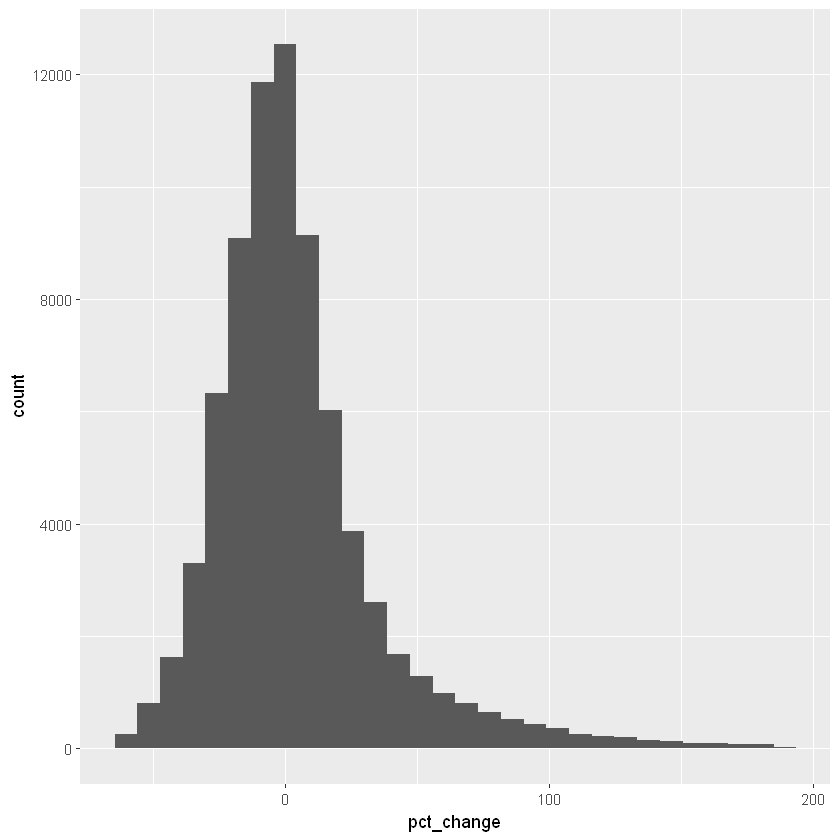

In [9]:
ggplot(lum_data, aes(x = pct_change)) + geom_histogram()

In [10]:
summary(lum_data$pct_change)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-60.356 -15.008  -1.289   4.276  15.034 189.360 

`geom_smooth()` using formula = 'y ~ x'


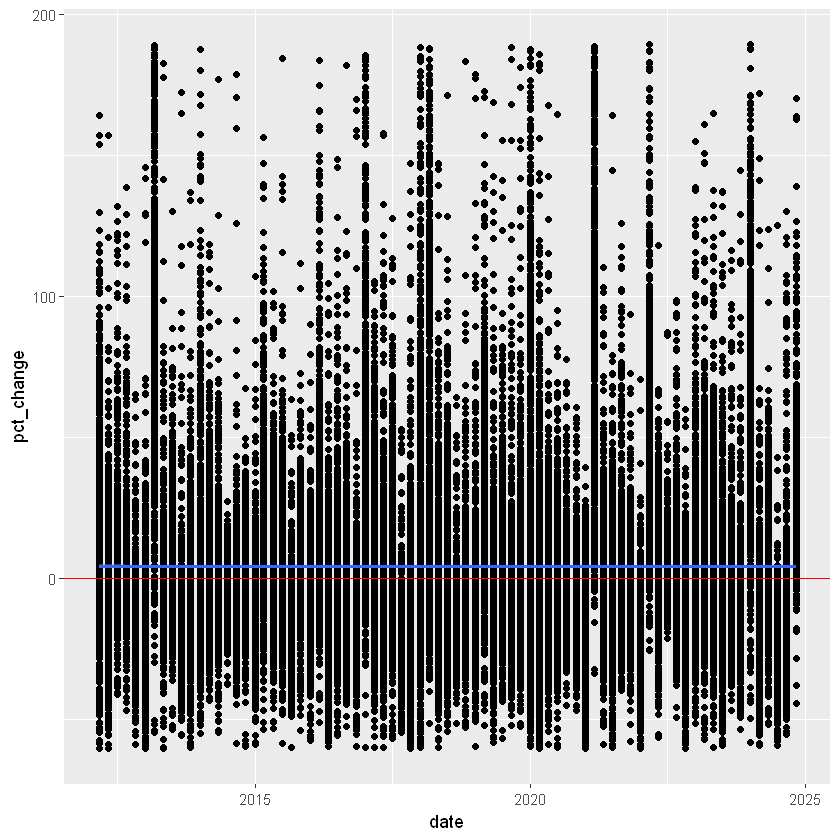

In [20]:
ggplot(lum_data, aes(x = date, y = pct_change)) + geom_point() + geom_hline(yintercept = 0, color = "red") + geom_smooth(method = 'lm')

`geom_smooth()` using formula = 'y ~ x'


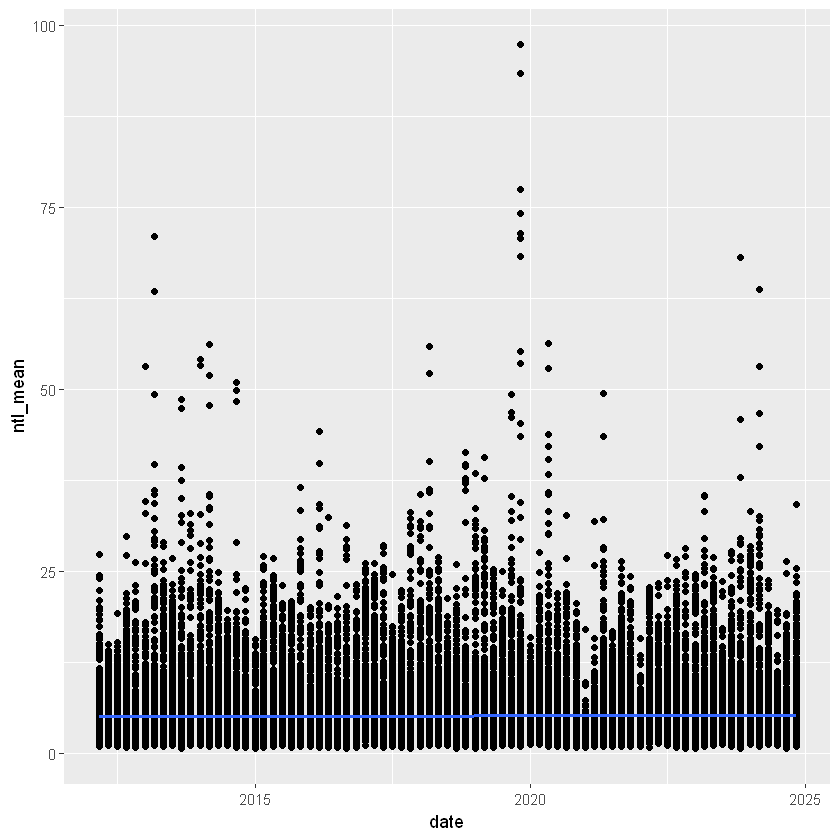

In [18]:
ggplot(lum_data, aes(x = date, y = ntl_mean)) + geom_point() + geom_smooth(method='lm')

In [19]:
reg0 <- lm(ntl_mean ~ date, data = lum_data)

summary(reg0)


Call:
lm(formula = ntl_mean ~ date, data = lum_data)

Residuals:
   Min     1Q Median     3Q    Max 
-4.565 -1.937 -1.079  0.528 92.192 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 4.724e+00  1.795e-01  26.320  < 2e-16 ***
date        2.652e-05  1.010e-05   2.625  0.00866 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.755 on 75504 degrees of freedom
Multiple R-squared:  9.127e-05,	Adjusted R-squared:  7.803e-05 
F-statistic: 6.892 on 1 and 75504 DF,  p-value: 0.008661
